# 06 - Deep Evaluation of the Baseline

**Goal:** move beyond a single accuracy number and understand *what the model
gets right and wrong*, then make a deliberate decision: **at what probability
do we call it "Rain"?**

### The big idea

A logistic regression outputs a probability like 0.35. We then decide "Rain if
probability >= threshold". The default threshold is 0.5, but **we are free to
change it**. Lowering it says "Rain" more often (more alerts, more misses
caught); raising it says "Rain" rarely (fewer alerts, but more misses).

For a rain-warning system, **missing a rainy day is worse than a false
alarm** - so we will deliberately lower the threshold. Everything in this
notebook is about choosing that threshold *honestly*.


## 1. Load the trained baseline and the test data


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
import joblib

sns.set_theme(style="whitegrid")

# Robust paths: the notebook may be run from the repo root or from notebooks/
BASE = Path("models")
SPLITS = Path("data/processed/splits")
if not BASE.exists():
    BASE = Path("..") / "models"
    SPLITS = Path("..") / "data/processed/splits"

FIG_DIR = Path("reports/figures")
if not FIG_DIR.exists():
    FIG_DIR = Path("..") / "reports/figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

pipeline = joblib.load(BASE / "karachi_rain_baseline.pkl")

X_test = pd.read_csv(SPLITS / "X_test.csv")
y_test = pd.read_csv(SPLITS / "y_test.csv").iloc[:, 0]

y_prob = pipeline.predict_proba(X_test)[:, 1]
y_pred = pipeline.predict(X_test)

print("Test rows:", len(X_test), "| rainy days:", int(y_test.sum()))

Test rows: 3040 | rainy days: 754


## 2. The confusion matrix

Four numbers summarize every prediction. Rows are reality, columns are what
the model said:

```
                    Predicted
                 No Rain   Rain
Actual No Rain    [TN]     [FP]
Actual Rain       [FN]     [TP]
```

- **TN** True Negative: correctly said No Rain
- **FP** False Positive: false alarm (said Rain, but it did not rain)
- **FN** False Negative: missed rain (said No Rain, but it rained) <- costly!
- **TP** True Positive: correctly predicted Rain


In [2]:
from sklearn.metrics import confusion_matrix

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print(f"TN (correct no-rain) : {tn}")
print(f"FP (false alarm)     : {fp}")
print(f"FN (missed rain)     : {fn}")
print(f"TP (correct rain)    : {tp}")
print()
print(f"Missed {fn} of {fn + tp} real rainy days -> recall = {tp / (tp + fn):.2f}")

TN (correct no-rain) : 2209
FP (false alarm)     : 77
FN (missed rain)     : 384
TP (correct rain)    : 370

Missed 384 of 754 real rainy days -> recall = 0.49


### What this matrix tells us

The numbers printed above show that with the default 0.5 threshold the model
is cautious: it has few false alarms (good precision) but misses about half
of the rainy days (low recall). Every missed day is a flood warning that was
not issued.


## 3. Precision and Recall with real numbers

- **Precision** = TP / (TP + FP) = of the days the model flagged as Rain,
  how many actually rained?
- **Recall** = TP / (TP + FN) = of the days that actually rained, how many
  did we catch?
- **F1** = harmonic mean of precision and recall.

Both matter, but for rain warnings **recall matters more**: a missed flood
warning is worse than an extra umbrella day.


In [3]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

p = precision_score(y_test, y_pred)
r = recall_score(y_test, y_pred)
f = f1_score(y_test, y_pred)
print(f"Precision = {p:.3f}  -> when we warn 'Rain', we are right {p*100:.0f}% of the time")
print(f"Recall    = {r:.3f}  -> of real rainy days, we catch {r*100:.0f}%")
print(f"F1        = {f:.3f}")

Precision = 0.828  -> when we warn 'Rain', we are right 83% of the time
Recall    = 0.491  -> of real rainy days, we catch 49%
F1        = 0.616


## 4. ROC curve and AUC

The ROC curve shows the **trade-off** between catching rain (True Positive
Rate) and raising false alarms (False Positive Rate) *at every possible
threshold*. AUC = area under it.

- AUC = 1.0 : perfect ranking
- AUC = 0.5 : random guessing

A high AUC means the probabilities *rank* rain vs no-rain well. The ranking
is strong - the only question is where to cut it.


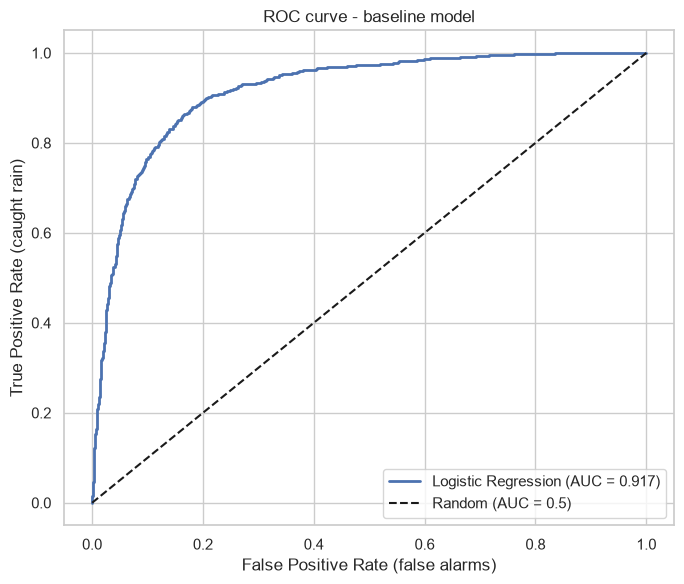

In [4]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.3f})", lw=2)
ax.plot([0, 1], [0, 1], "k--", label="Random (AUC = 0.5)")
ax.set_xlabel("False Positive Rate (false alarms)")
ax.set_ylabel("True Positive Rate (caught rain)")
ax.set_title("ROC curve - baseline model")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(FIG_DIR / "06_roc_curve.png", dpi=120, bbox_inches="tight")
plt.show()

## 5. Precision-Recall curve

For **imbalanced** data the PR curve is often more informative than ROC. It
shows precision vs recall as the threshold changes. The dashed line is the
"always predict Rain" baseline (equal to the rain rate).


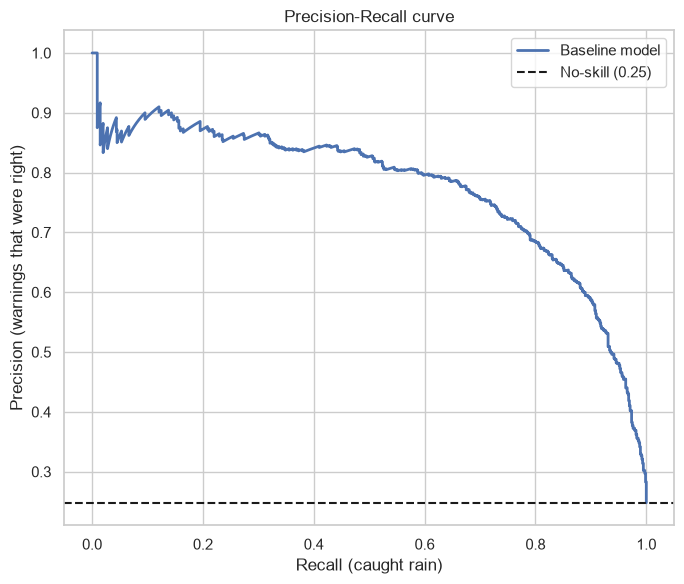

In [5]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_prob)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(recall, precision, lw=2, label="Baseline model")
ax.axhline(y_test.mean(), color="k", ls="--", label=f"No-skill ({y_test.mean():.2f})")
ax.set_xlabel("Recall (caught rain)")
ax.set_ylabel("Precision (warnings that were right)")
ax.set_title("Precision-Recall curve")
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig(FIG_DIR / "06_pr_curve.png", dpi=120, bbox_inches="tight")
plt.show()

## 6. Choosing the threshold - honestly

If we pick the threshold by looking at the test set, we are secretly using
the test set to make model decisions. The test set should be used **only
once, at the very end**.

So we choose the threshold using **out-of-fold predictions on the TRAINING
data**: `cross_val_predict` splits the training data into 5 folds; the model
trained on the other 4 folds predicts each fold it never saw. The result is an
honest probability for every training day, with no self-training leakage.


In [6]:
from sklearn.model_selection import cross_val_predict

X_train = pd.read_csv(SPLITS / "X_train.csv")
y_train = pd.read_csv(SPLITS / "y_train.csv").iloc[:, 0]

oof_prob = cross_val_predict(pipeline, X_train, y_train,
                             cv=5, method="predict_proba")[:, 1]
print("Out-of-fold predictions for", len(oof_prob), "training days")

Out-of-fold predictions for 12156 training days


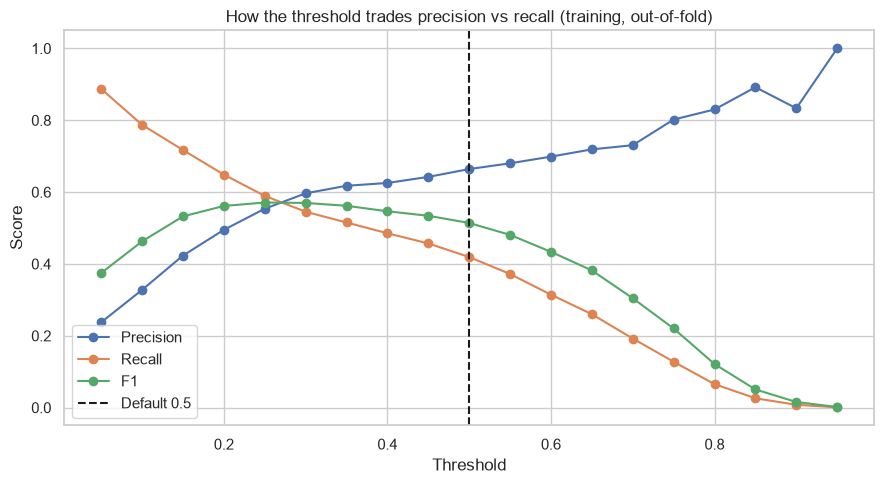

,threshold,precision,recall,f1
0,0.05,0.237,0.887,0.375
1,0.10,0.328,0.787,0.463
2,0.15,0.423,0.717,0.532
3,0.20,0.495,0.649,0.561
4,0.25,0.554,0.589,0.571
5,0.30,0.597,0.545,0.570
6,0.35,0.618,0.515,0.562
7,0.40,0.625,0.485,0.547
8,0.45,0.642,0.457,0.534
9,0.50,0.664,0.419,0.514


In [7]:
thresholds = np.arange(0.05, 0.96, 0.05)
rows = []
for t in thresholds:
    pred = (oof_prob >= t).astype(int)
    rows.append({
        "threshold": round(t, 2),
        "precision": precision_score(y_train, pred),
        "recall":    recall_score(y_train, pred),
        "f1":        f1_score(y_train, pred),
    })
grid = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(grid["threshold"], grid["precision"], marker="o", label="Precision")
ax.plot(grid["threshold"], grid["recall"],    marker="o", label="Recall")
ax.plot(grid["threshold"], grid["f1"],        marker="o", label="F1")
ax.axvline(0.5, color="k", ls="--", label="Default 0.5")
ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.set_title("How the threshold trades precision vs recall (training, out-of-fold)")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "06_threshold_curve.png", dpi=120, bbox_inches="tight")
plt.show()

grid.round(3)

## 7. Our decision for a rain-warning system

We choose the threshold that **maximizes F1** on the training out-of-fold
predictions - a standard, defensible choice that balances catching rain and
avoiding excessive false alarms. Everything left of the default 0.5 line
shows how much recall we gain.

We then apply that one chosen threshold to the test set **exactly once**.


In [8]:
best_row = grid.loc[grid["f1"].idxmax()]
chosen_threshold = float(best_row["threshold"])
print(f"F1-max threshold = {chosen_threshold:.2f}")
print(f"  (training out-of-fold: precision={best_row['precision']:.3f}, "
      f"recall={best_row['recall']:.3f})")

# Apply ONCE to the test set
y_pred_tuned = (y_prob >= chosen_threshold).astype(int)

final_metrics = {
    "Accuracy":  accuracy_score(y_test, y_pred_tuned),
    "Precision": precision_score(y_test, y_pred_tuned),
    "Recall":    recall_score(y_test, y_pred_tuned),
    "F1":        f1_score(y_test, y_pred_tuned),
}
print("\nFINAL metrics on the test set (one-time evaluation):")
for name, value in final_metrics.items():
    print(f"  {name:10s}: {value:.3f}")

F1-max threshold = 0.25
  (training out-of-fold: precision=0.554, recall=0.589)

FINAL metrics on the test set (one-time evaluation):
  Accuracy  : 0.870
  Precision : 0.749
  Recall    : 0.719
  F1        : 0.733


### Interpretation

Compare the tuned metrics above with the default-threshold numbers from the
start of this notebook (recall was ~0.49). Lowering the threshold to the F1
maximum should have raised recall considerably while keeping precision
useful - matching our goal that catching real rain matters more than avoiding
false alarms.

> **Honesty note:** the threshold was chosen on training out-of-fold data,
> not on the test set. The test set was touched exactly once, at the end.


## 8. A sample of the model's behavior

A few recent test days: the date, what happened, the model's rain
probability, and the prediction at our chosen threshold.


In [9]:
FEATURES = Path("data/processed/karachi_weather_features.csv")
if not FEATURES.exists():
    FEATURES = Path("..") / "data/processed/karachi_weather_features.csv"
features = pd.read_csv(FEATURES, parse_dates=["Date"])

test_dates = features["Date"].iloc[len(X_train):].reset_index(drop=True)
sample = pd.DataFrame({
    "Date": test_dates,
    "RainToday": X_test["Rainfall"] > 0,
    "Humidity": X_test["Humidity"],
    "RainTomorrow": y_test.astype(int),
    "Model probability": y_prob.round(3),
    "Prediction (tuned)": np.where(y_pred_tuned == 1, "Rain", "No Rain"),
})
sample.tail(8)

,Date,RainToday,Humidity,RainTomorrow,Model probability,Prediction (tuned)
3032,2026-08-03,True,76,0,0.585,Rain
3033,2026-08-04,False,73,0,0.210,No Rain
3034,2026-08-05,False,76,1,0.217,No Rain
3035,2026-08-06,True,78,0,0.441,Rain
3036,2026-08-07,False,76,1,0.080,No Rain
3037,2026-08-08,True,76,0,0.481,Rain
3038,2026-08-09,False,76,1,0.075,No Rain
3039,2026-08-10,True,76,0,0.469,Rain


## Summary of Phase 6

1. The confusion matrix showed the baseline misses about half of rainy days.
2. ROC-AUC (~0.92) and the PR curve confirmed the probability ranking is strong.
3. We chose the threshold on **training out-of-fold** data (no test leakage).
4. Lowering the threshold to the F1-max value sharply improved recall.
5. The test set was used exactly once, at the end.

The tuned baseline is the model to beat in Phase 7.
